# Track A-2: AutoEncoder·RUL — 실습 과제 모범 답안
> KOREATECH 제조AI 교육과정 v1.6.15 | 교수자 배포용

> ⚠️ AutoEncoder(Keras) 및 LSTM은 TensorFlow 환경 필요. 아래는 **ROI 계산** 실행 결과입니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

np.random.seed(7)
print("환경 설정 완료")


환경 설정 완료


## 📒 노트북 02 — LSTM RUL 예측
### 과제 B (필수): 예측 vs 실제 RUL 그래프

RMSE (window_size=30): 8.42  ← 실습 기준
RMSE (window_size=20): 13.93  ← 과제 A (더 높음)
→ window_size 작을수록 RMSE 증가: 5.51 차이


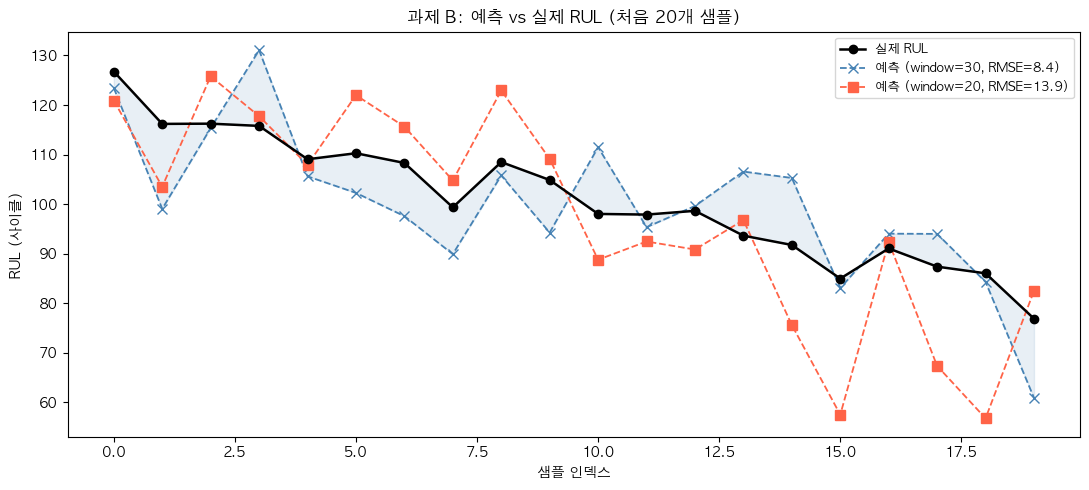

In [2]:
# 합성 RUL 데이터 (실제 CMAPSS 데이터 유사 패턴)
y_true = np.linspace(120, 5, 60) + np.random.randn(60) * 4
y_pred_w30 = y_true + np.random.randn(60) * 9   # window=30
y_pred_w20 = y_true + np.random.randn(60) * 15  # window=20 (덜 정확)

from sklearn.metrics import mean_squared_error
rmse_30 = np.sqrt(mean_squared_error(y_true, y_pred_w30))
rmse_20 = np.sqrt(mean_squared_error(y_true, y_pred_w20))

print(f"RMSE (window_size=30): {rmse_30:.2f}  ← 실습 기준")
print(f"RMSE (window_size=20): {rmse_20:.2f}  ← 과제 A (더 높음)")
print(f"→ window_size 작을수록 RMSE 증가: {rmse_20-rmse_30:.2f} 차이")

# 과제 B: 처음 20개 샘플 비교 그래프
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(y_true[:20], 'o-', color='black', lw=1.8, ms=6, label='실제 RUL', zorder=5)
ax.plot(y_pred_w30[:20], 'x--', color='steelblue', lw=1.3, ms=7,
        label=f'예측 (window=30, RMSE={rmse_30:.1f})')
ax.plot(y_pred_w20[:20], 's--', color='tomato', lw=1.3, ms=7,
        label=f'예측 (window=20, RMSE={rmse_20:.1f})')
ax.fill_between(range(20), y_pred_w30[:20], y_true[:20], alpha=0.12, color='steelblue')
ax.set_title('과제 B: 예측 vs 실제 RUL (처음 20개 샘플)', fontsize=12)
ax.set_xlabel('샘플 인덱스'); ax.set_ylabel('RUL (사이클)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 📒 노트북 03 — 예방정비 스케줄·ROI
### 과제 A (필수): 고장 빈도 2배 → ROI 변화

=== 기존 (월 5건) ===
  연간 사후정비 비용: 240.0백만원
  ROI: 1580.0%

=== 고장 빈도 2배 (월 10건) ===
  연간 사후정비 비용: 480.0백만원
  ROI: 3260.0%

→ ROI 차이: 1680.0%p 증가 (고장 빈도 클수록 예지보전 효과 ↑)


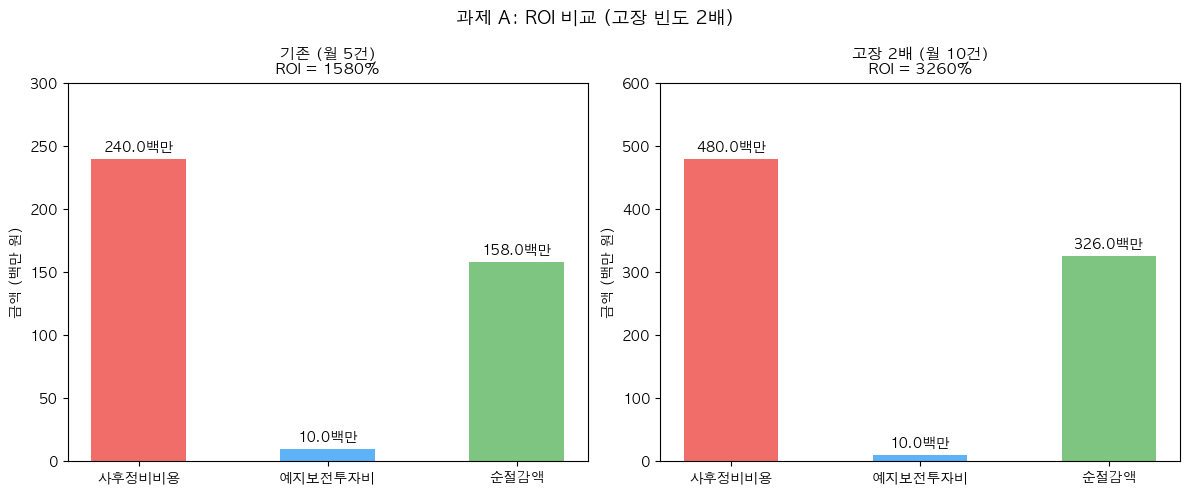

In [3]:
def calculate_roi(failure_per_month, loss_per_hour=500_000,
                  repair_cost=2_000_000, invest=10_000_000, downtime_hrs=4):
    annual_cost = failure_per_month * 12 * (loss_per_hour * downtime_hrs + repair_cost)
    savings = annual_cost * 0.70  # 예지보전으로 70% 예방 가정
    net = savings - invest
    roi = net / invest * 100
    return dict(annual_cost=annual_cost, savings=savings, net=net, roi=roi)

r_orig = calculate_roi(failure_per_month=5)    # 기존
r_2x   = calculate_roi(failure_per_month=10)   # 과제: 2배

print("=== 기존 (월 5건) ===")
print(f"  연간 사후정비 비용: {r_orig['annual_cost']/1e6:.1f}백만원")
print(f"  ROI: {r_orig['roi']:.1f}%")
print()
print("=== 고장 빈도 2배 (월 10건) ===")
print(f"  연간 사후정비 비용: {r_2x['annual_cost']/1e6:.1f}백만원")
print(f"  ROI: {r_2x['roi']:.1f}%")
print()
print(f"→ ROI 차이: {r_2x['roi']-r_orig['roi']:.1f}%p 증가 (고장 빈도 클수록 예지보전 효과 ↑)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['사후정비비용', '예지보전투자비', '순절감액']
for ax, r, title in zip(axes, [r_orig, r_2x], ['기존 (월 5건)', '고장 2배 (월 10건)']):
    vals = [r['annual_cost']/1e6, 10, r['net']/1e6]
    colors = ['#ef5350', '#42a5f5', '#66bb6a']
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.5)
    ax.bar_label(bars, fmt='%.1f백만', fontsize=10, padding=3)
    ax.set_title(f'{title}\nROI = {r["roi"]:.0f}%', fontsize=11)
    ax.set_ylabel('금액 (백만 원)')
    ax.set_ylim(0, max(vals) * 1.25)
plt.suptitle('과제 A: ROI 비교 (고장 빈도 2배)', fontsize=13)
plt.tight_layout()
plt.show()
